In [122]:
#installing libraries
!pip install numpy


[notice] A new release of pip is available: 26.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [123]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install sqlite3


[notice] A new release of pip is available: 26.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement sqlite3 (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for sqlite3


In [157]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [158]:
#import data/database
conn = sqlite3.connect('customer_churn.db')
sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type='table'
"""

tables = pd.read_sql(sql_query, conn)

# create datafram from each table we got in tables
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created Dataframe : df_{table_name}")

conn.close()
    

Created Dataframe : df_db_customer
Created Dataframe : df_db_subscription
Created Dataframe : df_db_support


In [159]:
#data cleaning -> Customer Table
df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [160]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [128]:
# rename col-name
# drop columns -> interests and pincode
# change datatype -> dob
# data standardization -> gender
# fix missing values -> country


In [161]:
df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

In [162]:
#df_db_customer.drop(df_db_customer.columns[-2:], axis=1, inplace= True)
#df_db_customer.columns[6:]

df_db_customer.drop(columns=['interests','pincode'], inplace= True)

In [163]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [164]:
df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [165]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [166]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [167]:
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
state_country_mapping

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

#review
df_db_customer[df_db_customer['country'].isna()]
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [168]:
#Subscription Table
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [169]:
df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
16,0020-JDNXP,2022-01-19,Organic,2024-01-19,Premium,Annual,NaN,NaN,20.99,550,62
17,0021-IKXGC,2021-07-07,Paid,2025-07-07,Standard,Annual,NaN,NaN,13.99,840,27
18,0022-TCJCI,2023-09-14,Refferal,2024-09-14,Basic,Monthly,2024-09-14,Forgot to cancel trial,16.99,42,99
19,0023-HGHWL,2020-06-23,Organic,2025-06-23,Premium,Annual,NaN,NaN,22.99,1955,7
20,0023-UYUPN,2022-12-31,Paid,2025-12-31,Standard,Monthly,NaN,NaN,13.99,790,47


In [170]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [171]:
date_col = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [172]:
# Table 3 ->  Support Table
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [173]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [174]:
df_db_support.drop(columns=['col_1','comment'], inplace= True)

In [175]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [176]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [177]:
# FEATURE ENGINEERING AND DATA ANALYSIS

In [178]:
# reloaded the data as change mistake was made on another column instead of the targeted one
conn = sqlite3.connect('customer_churn.db')

df_db_subscription = pd.read_sql("SELECT * FROM db_subscription", conn)

conn.close()

In [180]:
# created a new churn_flag column from the existed columns ->
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [181]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
 11  churn_flag               21 non-null     int64  
dtypes: float64(1), int64(3), str(8)
memory usage: 2.1 KB


In [149]:
# first fix df_db_support table duplicates then merge -> 
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left') )

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               23 non-null     str           
 1   subscription_start_date  23 non-null     str           
 2   subscription_type        23 non-null     str           
 3   renewal_date             23 non-null     str           
 4   plan_type                23 non-null     str           
 5   contract_type            23 non-null     str           
 6   cancellation_date        8 non-null      str           
 7   cancellation_reason      8 non-null      str           
 8   monthly_charges          23 non-null     float64       
 9   cltv                     23 non-null     int64         
 10  churn_score              23 non-null     int64         
 11  churn_flag               23 non-null     int64         
 12  customer_name            23 non-null     str     

In [151]:
df.shape

(23, 20)

In [206]:
# data mismatch found on JOIN as the overall table has 23 rows instead of an absolute 21 because of the df_db_support table which has 2 duplicate entries
# resolving the issue ->
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [207]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [208]:
# merge df here only -> 
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left') )

In [209]:
df.shape

(21, 21)

In [186]:
# df.to_csv('exported_churn_data.csv', index = False)

PermissionError: [Errno 13] Permission denied: 'exported_churn_data.csv'

In [ ]:
# DATA ANALYSIS ->

In [ ]:
# Churn Rate -> 

In [210]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [211]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [ ]:
# Retention Rate ->

In [212]:
retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [ ]:
# Churn By Plan Type ->

In [213]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,1.0


In [214]:
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
# ARPU -> Average Revenue Per User

In [215]:
arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu, 2))

ARPU =  18.85


In [ ]:
# Average Customer Tenure -> 
# Count of Days users has used our service : Cacellation date else Current date

In [216]:
df['subscription_start_date'] = pd.to_datetime(df['subscription_start_date'])
df['cancellation_date'] = pd.to_datetime(df['cancellation_date'])

In [217]:
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

# df.head()
avg_tenure = df['tenure_days'].mean()
print("Average Tenure (Days) = ", round(avg_tenure,0))

Average Tenure (Days) =  1509.0


In [ ]:
# Revenue at Risk -> Revenue Lost from Churned Users

In [218]:
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') = ", revenue_at_risk)

Revenue at Risk (Rs 'K') =  73.94


In [ ]:
# Escalation Rate ->

In [219]:
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate = ", round(escalation_rate, 2), "%")

Escalation Rate =  19.05 %


In [ ]:
# Average Complaint Per User ->

In [220]:
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Average Complaints Per User = ", round(avg_complaints, 2))

Average Complaints Per User =  0.33


In [ ]:
# Corelation Escalations Vs Churn

In [221]:
# df[['customerid', 'escalations', 'churn_flag']].dropna()
df[['escalations', 'churn_flag']].dropna()

# Encodind String to Integer type to facilitate the Operation
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation Between Escalation Vs Churn is = ", round(correlation, 2))

Correlation Between Escalation Vs Churn is =  0.77


In [ ]:
# Churn Risk -> Creating a New Column with the help of Existing Columns

In [223]:
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default = 'unknown')

In [224]:
df[['churn_risk', 'churn_score']].head(21)

,churn_risk,churn_score
0,low,12
1,high,91
2,low,34
3,low,8
4,high,88
5,low,22
6,high,79
7,low,5
8,low,34
9,low,41


In [ ]:
# Performing Data Visualisation using Matplotlib ->

In [225]:
# Creating a Copy of the Existing df Table so that beacause of any Further made changes Real Dta does not get Hindered in any way Possible -> 
df_visual = df.copy()

In [226]:
# Monthly Churn Trend -> (Showcasing Time Series KPI)

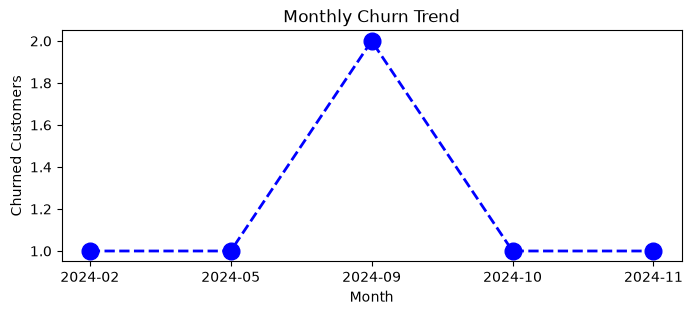

In [227]:
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize = (8,3) )
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='blue', marker='o', linestyle='dashed', linewidth=2, markersize=12)

# Attributes Added to he Chart
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

In [228]:
# Churn Trend Analysis on the Basis of the Plan Type ->

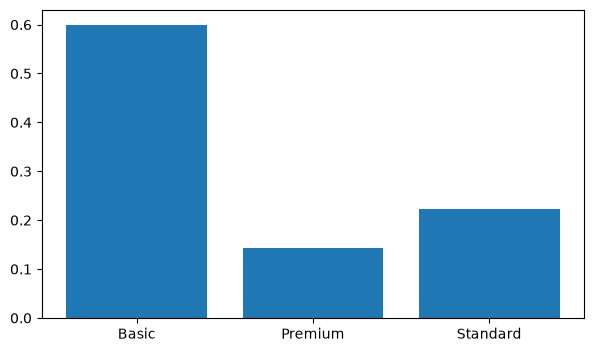

In [229]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

plt.figure(figsize = (7,4) )
# colors = ['yellow', 'purple', 'blue'] if we want the color effect to put as manually
#              OR
# colors = plt.sm.Set2(np.linspace(0, 1, len(churn_plan)))
# plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.bar(churn_plan.index, churn_plan.values)
plt.show()

In [230]:
# Churn Trend Analysis on the basis of State ->

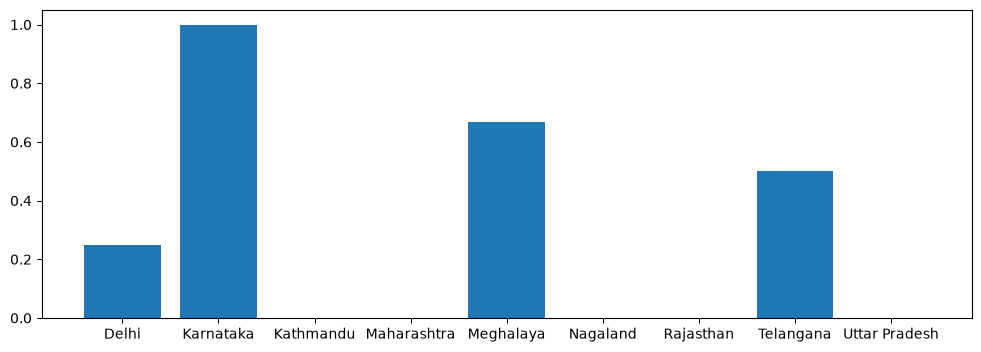

In [231]:
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

plt.figure(figsize = (12,4) )

plt.bar(churn_plan.index, churn_plan.values)
plt.show()

In [232]:
# Performing Data Visualization using Seaborn ->

In [233]:
# Heatmap Chart -> Showcases Correlation Matrix Between Escalation and Churn

In [234]:
import warnings
warnings.filterwarnings("ignore")

In [235]:
# Encoding -> Conversion of String to Numeric so that we can find Correlation Between Features

# this is an Incorrect Method of Encoding -> as numbers are not assigned based on priority here
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorical_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

df_encoded[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,0
1,1,0,91,1,0,1
2,0,1,34,0,1,0
3,1,0,8,0,1,0
4,2,1,88,1,0,1


<Axes: >

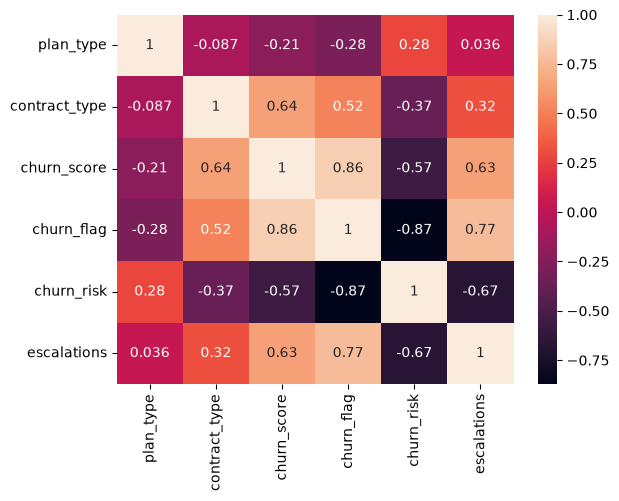

In [236]:
sns.heatmap(df_encoded.corr(), annot = True)

In [237]:
# Incorrect Method of Encoding -> as numbers are assigned based on priority here
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']
}

for col,order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

In [238]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [239]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

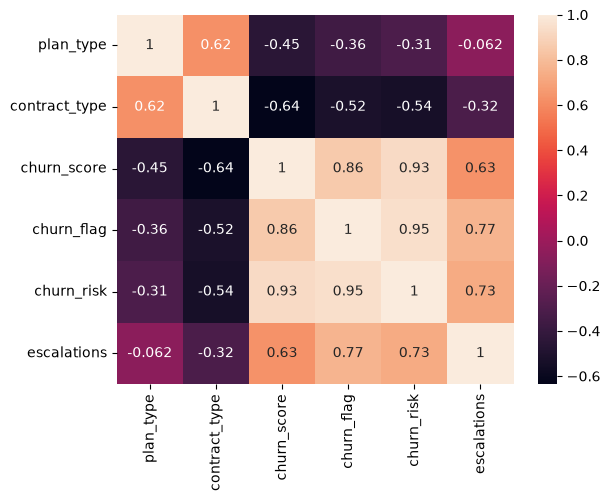

In [240]:
sns.heatmap(df_encoded.corr(), annot = True)

In [241]:
# PairPlot -> All the Relationships in a DataSet

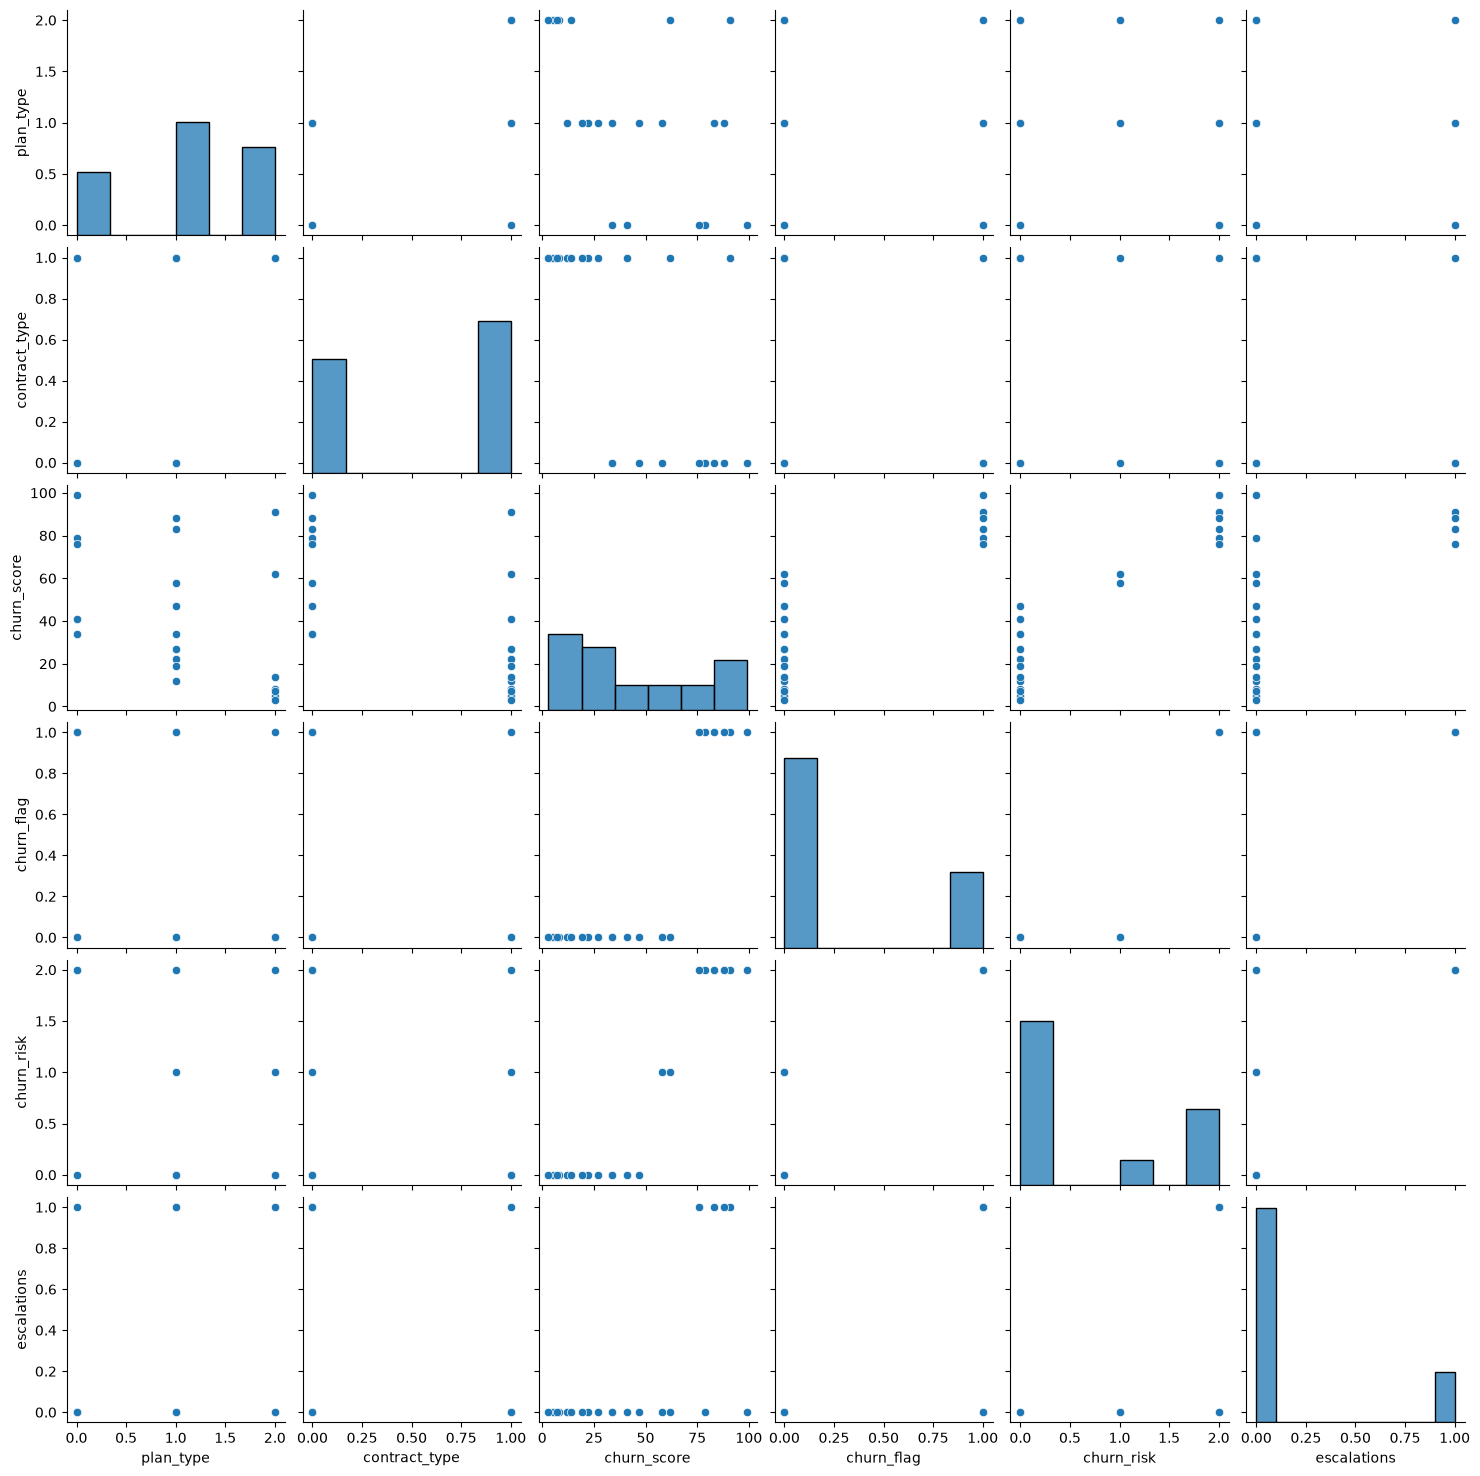

In [242]:
sns.pairplot(df_encoded)

In [243]:
# CatPlot OR Facegrid Plot -> Multi - Dimensional For the Comparison Aspect

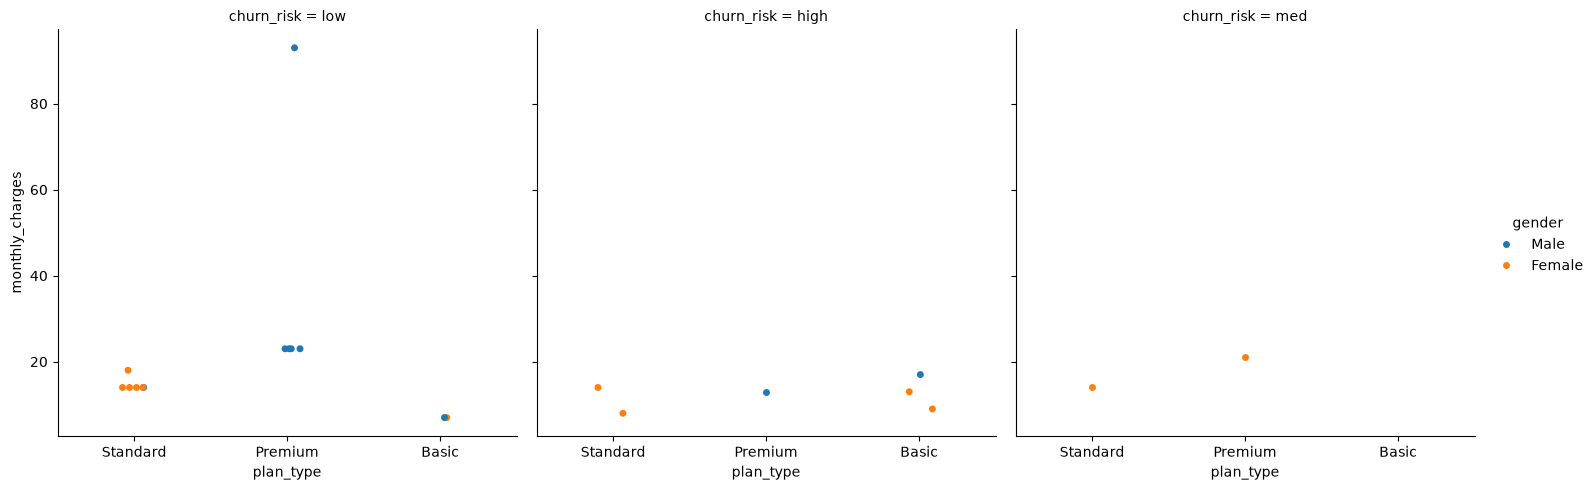

In [244]:
sns.catplot(data = df_visual,
            x = 'plan_type',
            y = 'monthly_charges',
            hue = 'gender',
            col = 'churn_risk'
           )
            

In [245]:
# Pivot Table ->

In [246]:
pd.pivot_table(
    df_visual,
    values = 'churn_flag',
    index = 'plan_type',
    aggfunc = 'mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [247]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = ['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc = {
        'monthly_charges' : 'sum', 
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91
